In [ ]:
# ============================================
# CONTEXTO DO NOTEBOOK
# ============================================
# Este notebook foi desenvolvido como atividade de ciência de dados durante o curso técnico.
#
# O objetivo era realizar uma análise exploratória simples a partir de um conjunto de dados
# contendo informações de alunos, como horas de estudo, notas e faltas.
#
# Aqui são aplicados conceitos fundamentais como:
# - leitura e inspeção de dados (pandas)
# - estatística descritiva
# - transformação de dados
# - regressão linear
# - correlação e análise de relação entre variáveis
# - visualização com gráficos
#
# Mesmo sendo um exercício, já demonstra organização de raciocínio analítico.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Leitura do dataset a partir de um arquivo Excel
df = pd.read_excel('atividade_ciencia_dados_3ano.xlsx')

# Visualização inicial dos dados (primeiras linhas)
df.head(5)

,Aluno,Idade,HorasEstudo_dia,NotaMatematica,NotaPortugues,Faltas,EstudaMaisQue2h
0,Aluno01,18,3.5,58.2,66.6,3,1
1,Aluno02,19,2.0,49.2,44.5,4,0
2,Aluno03,18,2.5,56.3,58.6,2,1
3,Aluno04,18,1.0,53.5,58.4,3,0
4,Aluno05,17,1.5,52.7,46.6,5,0


In [ ]:
# Exibição da estrutura do dataset (tipos de dados e valores não nulos)
df.info()

# Estatísticas descritivas básicas (média, desvio padrão, quartis, etc.)
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Aluno            24 non-null     object 
 1   Idade            24 non-null     int64  
 2   HorasEstudo_dia  24 non-null     float64
 3   NotaMatematica   24 non-null     float64
 4   NotaPortugues    24 non-null     float64
 5   Faltas           24 non-null     int64  
 6   EstudaMaisQue2h  24 non-null     int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 1.4+ KB


,Idade,HorasEstudo_dia,NotaMatematica,NotaPortugues,Faltas,EstudaMaisQue2h
count,24.000000,24.000000,24.000000,24.000000,24.0000,24.000000
mean,17.833333,2.000000,54.695833,51.545833,2.8750,0.416667
std,0.701964,0.920775,11.202309,12.462848,1.2619,0.503610
min,17.000000,0.000000,33.500000,16.800000,1.0000,0.000000
25%,17.000000,1.375000,48.125000,46.825000,2.0000,0.000000
50%,18.000000,2.000000,53.950000,50.400000,3.0000,0.000000
75%,18.000000,2.500000,58.625000,58.975000,4.0000,1.000000
max,19.000000,4.000000,82.500000,73.800000,5.0000,1.000000


In [ ]:
# Cálculo de métricas estatísticas para horas de estudo
print("Média horas:", df['HorasEstudo_dia'].mean())
print("Mediana horas:", df['HorasEstudo_dia'].median())
print("Desvio padrão horas:", df['HorasEstudo_dia'].std())

# Cálculo de métricas estatísticas para notas de matemática
print("Média nota matemática:", df['NotaMatematica'].mean())
print("Mediana nota matemática:", df['NotaMatematica'].median())
print("Desvio padrão nota matemática:", df['NotaMatematica'].std())

Média horas: 2.0
Mediana horas: 2.0
Desvio padrão horas: 0.920774721067277
Média nota matemática: 54.695833333333326
Mediana nota matemática: 53.95
Desvio padrão nota matemática: 11.202308735903182


In [ ]:
# Criação de uma nova coluna categórica baseada na nota
# Classificação simples: aprovado ou em recuperação
df['Aprovacao'] = df['NotaMatematica'].apply(
    lambda x: 'Aprovado' if x >= 60 else 'Recuperacao'
)

# Visualização das colunas relevantes após transformação
df[['Aluno','NotaMatematica','Aprovacao']].head()

,Aluno,NotaMatematica,Aprovacao
0,Aluno01,58.2,Recuperacao
1,Aluno02,49.2,Recuperacao
2,Aluno03,56.3,Recuperacao
3,Aluno04,53.5,Recuperacao
4,Aluno05,52.7,Recuperacao


In [ ]:
# Cálculo da frequência absoluta de faltas
freq = df['Faltas'].value_counts().sort_index()

# Cálculo da frequência relativa (proporção em relação ao total)
freq_rel = freq / len(df)

# Exibição das frequências em formato de tabela
print(pd.DataFrame({
    "Frequência": freq,
    "Frequência Relativa": freq_rel
}))

        Frequência  Frequência Relativa
Faltas                                 
1                4             0.166667
2                5             0.208333
3                8             0.333333
4                4             0.166667
5                3             0.125000


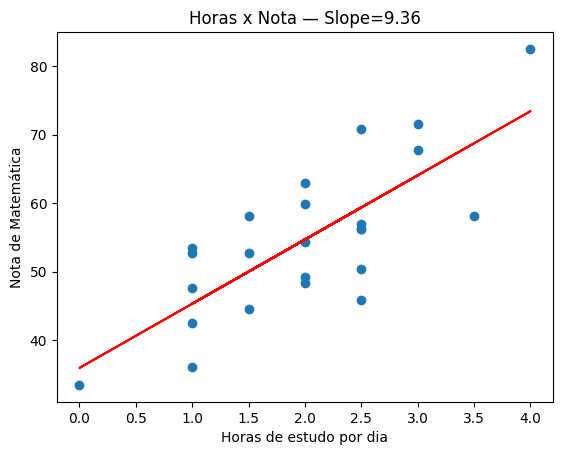

In [ ]:
# Definição das variáveis para análise de regressão
x = df['HorasEstudo_dia']
y = df['NotaMatematica']

# Ajuste de uma regressão linear (reta de melhor ajuste)
slope, intercept = np.polyfit(x, y, 1)
y_pred = slope*x + intercept

# Plot dos dados reais (scatter) e da linha de regressão
plt.scatter(x, y)
plt.plot(x, y_pred, color='red')

# Rotulação do gráfico
plt.xlabel('Horas de estudo por dia')
plt.ylabel('Nota de Matemática')
plt.title(f'Horas x Nota — Slope={slope:.2f}')

plt.show()

In [ ]:
# Cálculo do coeficiente de determinação (R²)
# Mede o quanto o modelo explica a variabilidade dos dados
ss_res = ((y - y_pred)**2).sum()
ss_tot = ((y - y.mean())**2).sum()
r2 = 1 - ss_res/ss_tot

# Cálculo da correlação entre as variáveis
corr = np.corrcoef(x, y)[0,1]

print("R2:", r2)
print("Correlação:", corr)

R2: 0.5917635552248264
Correlação: 0.7692616948898641


In [ ]:
# Cálculo da probabilidade de aprovação (nota >= 60)
prob_aprov = (df['NotaMatematica'] >= 60).mean()

print("Probabilidade de aprovação:", prob_aprov*100, "%")

Probabilidade de aprovação: 20.833333333333336 %


/tmp/ipython-input-1398660335.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([grupo_menos2, grupo_mais2], labels=['≤2h','>2h'])


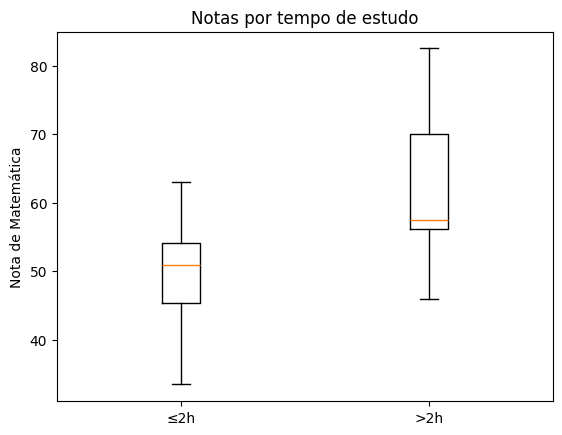

In [ ]:
# Separação dos dados em dois grupos:
# - alunos que estudam até 2h por dia
# - alunos que estudam mais de 2h por dia
grupo_mais2 = df[df['HorasEstudo_dia'] > 2]['NotaMatematica']
grupo_menos2 = df[df['HorasEstudo_dia'] <= 2]['NotaMatematica']

# Visualização da distribuição das notas com boxplot
plt.boxplot([grupo_menos2, grupo_mais2], labels=['≤2h','>2h'])

plt.ylabel('Nota de Matemática')
plt.title('Notas por tempo de estudo')

plt.show()

In [ ]:
# ============================================
# INTERPRETAÇÃO DOS RESULTADOS
# ============================================

# - Alunos que estudam mais de 2h por dia apresentam, em média,
#   uma mediana de notas maior.

# - O valor de R² indica que existem outros fatores influenciando
#   o desempenho além das horas de estudo.

# - A probabilidade de aprovação foi calculada com base na proporção
#   de alunos com nota maior ou igual a 60.